In [1]:
import scvelo as scv
import scanpy as sc
import gsnn
import torch
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import r2_score

%reload_ext autoreload
%autoreload 2


In [2]:
adata = scv.datasets.pancreas()

In [3]:
scv.pp.filter_genes(adata, min_shared_counts=20)
scv.pp.normalize_per_cell(adata)
sc.pp.filter_genes_dispersion(adata, n_top_genes=2000)
sc.pp.log1p(adata)

Filtered out 20801 genes that are detected 20 counts (shared).
Normalized count data: X, spliced, unspliced.


In [4]:
scv.pp.moments(adata, n_pcs=30, n_neighbors=30)

/tmp/ipykernel_28713/62146136.py:1: DeprecationWarning: Automatic neighbor calculation is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors first with Scanpy.
  scv.pp.moments(adata, n_pcs=30, n_neighbors=30)
/home/teddy/miniconda3/envs/gsnn-mds/lib/python3.12/site-packages/scvelo/preprocessing/moments.py:71: DeprecationWarning: `neighbors` is deprecated since scvelo==0.4.0 and will be removed in a future version of scVelo. Please compute neighbors with Scanpy.
  neighbors(


computing neighbors
    finished (0:00:04) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [5]:
scv.tl.velocity(adata)

computing velocities


/home/teddy/miniconda3/envs/gsnn-mds/lib/python3.12/site-packages/scvelo/tools/optimization.py:184: DeprecationWarning: Conversion of an array with ndim > 0 to a scalar is deprecated, and will error in future. Ensure you extract a single element from your array before performing this operation. (Deprecated NumPy 1.25.)
  gamma[i] = np.linalg.pinv(A.T.dot(A)).dot(A.T.dot(y[:, i]))


    finished (0:00:01) --> added 
    'velocity', velocity vectors for each individual cell (adata.layers)


In [6]:
scv.tl.velocity_graph(adata)

computing velocity graph (using 1/24 cores)


  0%|          | 0/3696 [00:00<?, ?cells/s]

/home/teddy/miniconda3/envs/gsnn-mds/lib/python3.12/multiprocessing/popen_fork.py:66: DeprecationWarning: This process (pid=28713) is multi-threaded, use of fork() may lead to deadlocks in the child.
  self.pid = os.fork()


    finished (0:00:10) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


computing velocity embedding
    finished (0:00:00) --> added
    'velocity_umap', embedded velocity vectors (adata.obsm)


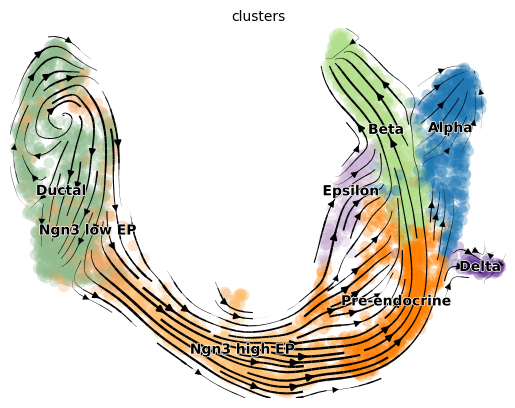

In [7]:
scv.pl.velocity_embedding_stream(adata, basis='umap')


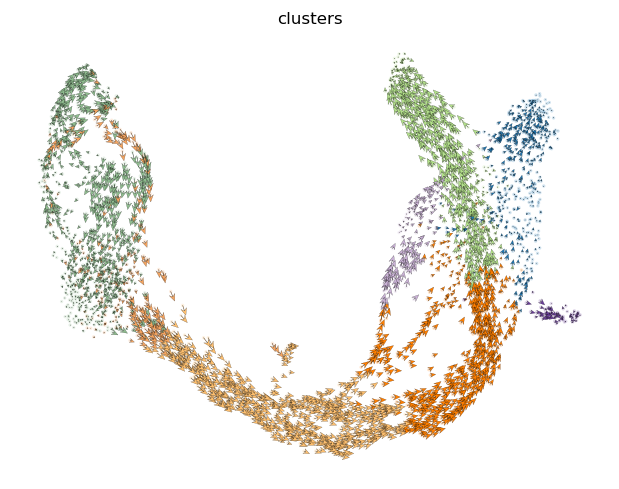

In [8]:
scv.pl.velocity_embedding(adata, arrow_length=3, arrow_size=2, dpi=120)

In [9]:
# expression is X 
# velocity is y 

X = torch.tensor(adata.X.toarray(), dtype=torch.float32)
y = torch.tensor(adata.layers['velocity'], dtype=torch.float32)

gene_names = [x.upper() for x in adata.var_names.tolist()] 
input_names = ['IN__' + g for g in gene_names]
output_names = ['OUT__' + g for g in gene_names]

print('# genes:', len(gene_names))
print(X.shape)
print(y.shape)

dataset = torch.utils.data.TensorDataset(X, y)
loader = torch.utils.data.DataLoader(dataset, batch_size=128, shuffle=True)


# genes: 2000
torch.Size([3696, 2000])
torch.Size([3696, 2000])


In [10]:
func_names, func_df = gsnn.proc.bio.get_bio_interactions(undirected=False, include_mirna=False, include_extra=False, dorothea_levels=['A', 'B'], gene_symbol=True, verbose=True) 

loading omnipath interactions...
	dorothea...
	omnipath...
# of translation edges (RNA->PROTEIN): 3243


In [11]:
frnas = [x.split('__')[1] for x in func_names if 'RNA' in x]
overlap = set(frnas) & set(gene_names)

good_inputs = np.isin(np.array(gene_names), np.array(list(overlap))) 

input_names = ['IN__' + g for g in np.array(gene_names)[good_inputs]]
output_names = ['OUT__' + g for g in np.array(gene_names)[good_inputs]]

X = X[:, good_inputs] 
y = y[:, good_inputs] 

print(X.shape)
print(y.shape)


torch.Size([3696, 815])
torch.Size([3696, 815])


In [12]:
x_mu = X.mean(dim=0)
x_std = X.std(dim=0)
X = (X - x_mu) / x_std

# y_mu = y.mean(dim=0) # we don't want to shift the velocity; 0 is no change    
y_std = y.std(dim=0)
y = (y) / y_std

In [13]:
input_edges = pd.DataFrame({'src': input_names, 'dst': ['RNA__' + g.split('__')[1] for g in input_names], 'edge_type': 'input'})
output_edges = pd.DataFrame({'src': ['RNA__' + g.split('__')[1] for g in output_names], 'dst': output_names, 'edge_type': 'output'})

In [14]:
net_builder = gsnn.proc.construct.GSNNNetworkConstructor(depth = 6, verbose= True) 

data = net_builder.build(input_edges = input_edges , 
                        function_edges = func_df, 
                        output_edges = output_edges, 
                        mediator_edges=None,
                        input_names=input_names,
                        output_names=output_names,
                        function_names=func_names,
                        mediator_names=None)

building candidate network...
subgraph progress: 815/815

Network Construction Summary:
Inputs: 815 included, 0 removed
Mediators: 0 included, 0 removed
Functions: 13978 included, 0 removed
Outputs: 815 included, 0 removed
Isolated nodes: 0 inputs, 0 outputs

Graph Statistics:
  Nodes: 15608
  Edges: 11120
  Density: 0.0000
  Avg Degree: 1.42
  Avg Clustering: 0.0456



In [15]:
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')

model = gsnn.models.GSNN.GSNN(edge_index_dict = data['edge_index_dict'], 
                                node_names_dict = data['node_names_dict'], 
                                channels = 5, 
                                layers = 6, 
                                dropout=0., 
                                nonlin=torch.nn.ELU, 
                                bias=True, 
                                share_layers=False, 
                                add_function_self_edges=True, 
                                norm='batch', 
                                init='degree_normalized', 
                                verbose=False, 
                                edge_channels=1, 
                                checkpoint=True, 
                                residual=True, 
                                norm_first=True, 
                                node_attn=False, 
                                node_mlp=True, 
                                node_mlp_hidden=128, 
                                edge_weight_dict=None).to(device)

print('# params:', sum(p.numel() for p in model.parameters()))

                         

# params: 2875608


In [16]:
optim = torch.optim.Adam(model.parameters(), lr=1e-3)
crit = torch.nn.MSELoss() 
                         

In [17]:
dataset = torch.utils.data.TensorDataset(X, y)
loader = torch.utils.data.DataLoader(dataset, batch_size=512, shuffle=True, drop_last=True)

In [18]:
torch.cuda.empty_cache()

In [19]:

for epoch in range(100):
    loss_ = 0; r2_ = 0; r_ = 0
    for xx,yy in loader:
        xx = xx.to(device)
        yy = yy.to(device)
        optim.zero_grad()
        y_pred = model(xx)
        loss = crit(y_pred, yy)
        loss.backward()
        optim.step()

        r2 = r2_score(yy.detach().cpu().numpy(), y_pred.detach().cpu().numpy(), multioutput='uniform_average')
        r = np.corrcoef(yy.detach().cpu().numpy().ravel(), y_pred.detach().cpu().numpy().ravel())[0, 1] 

        r2_ = r2_ + r2
        loss_ = loss_ + loss.item()
        r_ = r_ + r

    print(f'Epoch {epoch+1} loss: {loss_/len(loader):.3f}, r2: {r2_/len(loader):.3f}, r: {r_/len(loader):.3f}')

Epoch 1 loss: 1.282, r2: -0.284, r: 0.081
Epoch 2 loss: 1.217, r2: -0.222, r: 0.211
Epoch 3 loss: 1.157, r2: -0.161, r: 0.290
Epoch 4 loss: 1.091, r2: -0.094, r: 0.360
Epoch 5 loss: 1.029, r2: -0.033, r: 0.416
Epoch 6 loss: 0.980, r2: 0.016, r: 0.459
Epoch 7 loss: 0.944, r2: 0.055, r: 0.490
Epoch 8 loss: 0.916, r2: 0.082, r: 0.512
Epoch 9 loss: 0.895, r2: 0.102, r: 0.528
Epoch 10 loss: 0.880, r2: 0.118, r: 0.540
Epoch 11 loss: 0.868, r2: 0.130, r: 0.548
Epoch 12 loss: 0.859, r2: 0.140, r: 0.556
Epoch 13 loss: 0.850, r2: 0.148, r: 0.561
Epoch 14 loss: 0.843, r2: 0.155, r: 0.567
Epoch 15 loss: 0.836, r2: 0.163, r: 0.572
Epoch 16 loss: 0.829, r2: 0.169, r: 0.576
Epoch 17 loss: 0.823, r2: 0.175, r: 0.580
Epoch 18 loss: 0.819, r2: 0.179, r: 0.583
Epoch 19 loss: 0.814, r2: 0.184, r: 0.587
Epoch 20 loss: 0.809, r2: 0.189, r: 0.590
Epoch 21 loss: 0.804, r2: 0.193, r: 0.593
Epoch 22 loss: 0.800, r2: 0.197, r: 0.596
Epoch 23 loss: 0.798, r2: 0.201, r: 0.598
Epoch 24 loss: 0.793, r2: 0.205, r: 0.

In [20]:
model.eval()

x_smol = X[[0]].view(1, -1)
y_smol = y[[0]]
with torch.no_grad():
    yhat_smol = model(x_smol.to(device)) 

top_ixs = torch.argsort(yhat_smol.view(-1), dim=0, descending=True)[0:3]
print(top_ixs)
max_vel = yhat_smol[0, top_ixs]
print(top_ixs, max_vel)

tensor([235, 710, 374], device='cuda:0')
tensor([235, 710, 374], device='cuda:0') tensor([3.0771, 2.9272, 2.7793], device='cuda:0')


In [30]:
from gsnn.interpret.GSNNExplainer import GSNNExplainer
from gsnn.interpret.utils import plot_edge_importance

model.eval()
torch.cuda.empty_cache()

target_ixs = [235]

explainer = GSNNExplainer(model, data, ignore_cuda=False, gumbel_softmax=True, hard=True, tau0=10, min_tau=0.5,
                            prior=1, iters=1000, lr=1e-2, weight_decay=0, beta=1e-2, verbose=True,
                            optimizer=torch.optim.Adam, free_edges=25)

x_smol = X[[0]]
res = explainer.explain(x_smol.to(device), target_idx=target_ixs)

iter: 999 | loss: 1.6540 | mse: 0.0140 | r2: -666.000 | active edges: 189 / 25098 | entropy: 0.01157075
POST-TRAINING EVALUATION (edges > 0.5)
Selected edges: 135 / 25098 (0.5%)
MSE (subset): 0.050673
R² (subset): nan
Variance explained: 0.0000
Correlation: nan


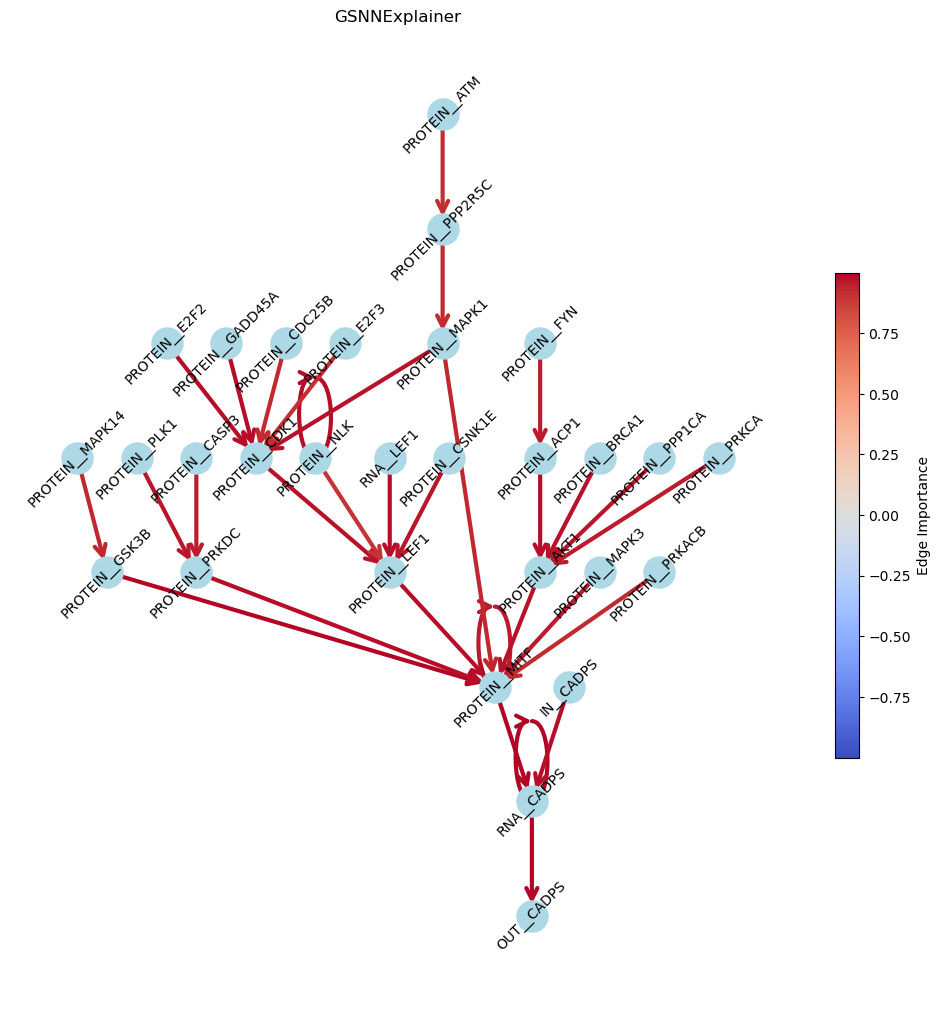

In [31]:
plot_edge_importance(res.sort_values('score', ascending=False).head(50), title='GSNNExplainer', figsize=(10, 10), leafs=np.array(output_names)[target_ixs])

In [32]:
from gsnn.interpret.IGExplainer import IGExplainer

explainer = IGExplainer(model, data)
res_ig = explainer.explain(x_smol.to(device), target_idx=target_ixs)

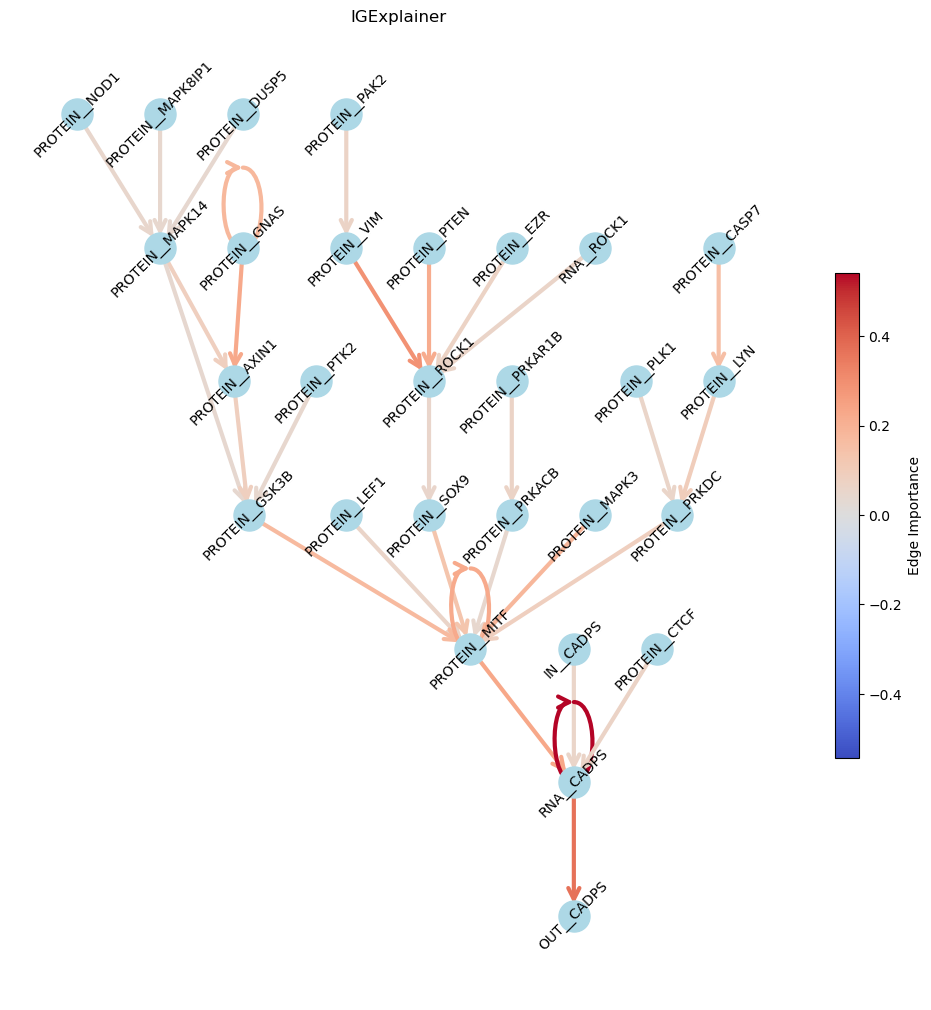

In [33]:
plot_edge_importance(res_ig.sort_values('score', ascending=False).head(100), title='IGExplainer', figsize=(10, 10), leafs=np.array(output_names)[target_ixs])